데이터 로드

데이터 출처 링크 : https://github.com/bab2min/corpus/tree/master/sentiment

In [1]:
import re   # 정규표현식
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import urllib.request
from collections import Counter
from sklearn.model_selection import train_test_split

## 문제 생길 경우 드라이브 ./data에 naver_shopping.txt 다운로드받아놓았으니 활용 가능

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = '/content/drive/MyDrive/한시경_교육사업부_2024/[공식] 생성형_AI/강의안(외부유출_절대금지)_완성코드 /01_OPENAI_API/data/naver_shopping.txt'

In [3]:
# 전체 데이터에 해당하는 naver_shopping.txt 다운로드 하기
urllib.request.urlretrieve("https://raw.githubusercontent.com/ukairia777/tensorflow-nlp-tutorial/main/10.%20RNN%20Text%20Classification/dataset/naver_shopping.txt", filename="naver_shopping.txt")

('naver_shopping.txt', <http.client.HTTPMessage at 0x7bc0960d8850>)

In [4]:
pd.read_table('naver_shopping.txt')

,5,배공빠르고 굿
0,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고
1,5,아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 ...
2,2,선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전...
3,5,민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요 ㅎㅎ
4,2,비추합니다 계란 뒤집을 때 완전 불편해요 ㅠㅠ 코팅도 묻어나고 보기엔 예쁘고 실용적...
...,...,...
199994,2,장마라그런가!!! 달지않아요
199995,5,다이슨 케이스 구매했어요 다이슨 슈퍼소닉 드라이기 케이스 구매했어요가격 괜찮고 배송...
199996,5,로드샾에서 사는것보다 세배 저렴하네요 ㅜㅜ 자주이용할께요
199997,5,넘이쁘고 쎄련되보이네요~


In [5]:
total_data = pd.read_table('naver_shopping.txt', names=['ratings', 'reviews'])
# 열 제목 생성('ratings', 'reviews')
total_data[:5]

,ratings,reviews
0,5,배공빠르고 굿
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고
2,5,아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 ...
3,2,선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전...
4,5,민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요 ㅎㅎ


In [6]:
print('전체 리뷰 개수: ', len(total_data))

전체 리뷰 개수:  200000


In [7]:
total_data['ratings'].value_counts()

,count
ratings,
5,81177
2,63989
1,36048
4,18786


훈련용 데이터와 테스트데이터 분리

In [8]:
condition = (total_data.ratings > 3)
total_data[condition]

,ratings,reviews
0,5,배공빠르고 굿
2,5,아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 ...
4,5,민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요 ㅎㅎ
10,5,사이즈도 딱이고 귀엽고 넘 좋아요 ㅎㅎ
14,5,촉감도 좋고 무게감이나 핏도 편합니다
...,...,...
199994,4,전반적으로 어플이나 각종 IOT서비스와의 완성도는 좋음 그러나 서버의 잦은 다운과 ...
199996,5,다이슨 케이스 구매했어요 다이슨 슈퍼소닉 드라이기 케이스 구매했어요가격 괜찮고 배송...
199997,5,로드샾에서 사는것보다 세배 저렴하네요 ㅜㅜ 자주이용할께요
199998,5,넘이쁘고 쎄련되보이네요~


In [9]:
# 긍정 (평점이 4점, 5점 >> 1, 평점이 1점, 2점 >> 0)

np.select([total_data.ratings > 3], [1], default=0)
# np.select(condition, choice, default=0)
# >> condition 조건이 참(True= 1) choice, 그렇지 않으면 0

array([1, 0, 1, ..., 1, 1, 1])

In [10]:
total_data['label'] = np.select([total_data.ratings > 3], [1], default=0)
total_data[:5]

,ratings,reviews,label
0,5,배공빠르고 굿,1
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고,0
2,5,아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 ...,1
3,2,선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전...,0
4,5,민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요 ㅎㅎ,1


In [11]:
# 각 열에 대해서 중복 제외 샘플 카운팅 하기

total_data['ratings'].nunique() # nunique() : number of uniquesness
# >> 1,2,4,5

4

In [12]:
total_data['reviews'].nunique()

199908

In [13]:
total_data['label'].nunique()

2

In [14]:
total_data.drop_duplicates(subset=['reviews'], inplace=True)
# in place of ~ : ~을 대신하다
# 'reviews' 열에서 중복인 내용 >> 중복 제거

In [15]:
print('총 샘플 수: ', len(total_data))

총 샘플 수:  199908


In [16]:
# 결측치 확인
total_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 199908 entries, 0 to 199999
Data columns (total 3 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   ratings  199908 non-null  int64 
 1   reviews  199908 non-null  object
 2   label    199908 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 6.1+ MB


In [17]:
total_data.isnull().sum()

,0
ratings,0
reviews,0
label,0


In [18]:
total_data.isnull().values.any()

False

In [19]:
# 훈련용 데이터 : 테스트 데이터 = 3 : 1

train_data, test_data =\
train_test_split(total_data, test_size=0.25, random_state=42 )
# random_state=42 무작위, 임의로 섞은 샘플 중 하나(42번째) 분석에 사용하겠다는 의미

In [20]:
print('훈련용 리뷰의 개수: ', len(train_data))
print('테스트용 리뷰의 개수: ', len(test_data))

훈련용 리뷰의 개수:  149931
테스트용 리뷰의 개수:  49977


In [21]:
# 모델링 (train_data)

train_data.head()

,ratings,reviews,label
59666,2,사이즈를 3센치씩 늘린건데도 작아요 그리고 색상은 완전 달라요 칙칙한핑크네요ㅠㅠ 많...,0
12433,2,ㅂ불만족.. 빗이 아픔 .. 멍이피부에 빗질못해주겟네요,0
146516,1,이 제품쓰고 삼일만에 변기물이 잘 안내려갔어요. 혹시나해서 다시 빼보니 물이 다시 ...,0
158109,5,적당하고 만족합니다,1
70219,2,편하자고 이용하는 밀키튼데 손 은근 많이 가서 저는 패쓰요,0


In [22]:
# EDA (탐색적 데이터 분석)

train_data['label'].value_counts()

,count
label,
1,75013
0,74918


<Axes: xlabel='label'>

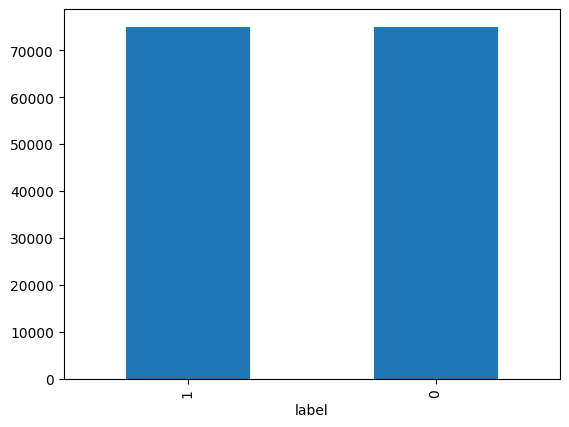

In [23]:
train_data['label'].value_counts().plot(kind='bar')

In [24]:
train_data.groupby('label').size()

,0
label,
0,74918
1,75013


In [25]:
train_data.groupby('label').size().reset_index(name='count')

,label,count
0,0,74918
1,1,75013


실전 모델링_감성분석

In [26]:
!pip install transformers

In [27]:
# https://huggingface.co/
# https://huggingface.co/matthewburke/korean_sentiment


from transformers import pipeline
classifier = pipeline("text-classification", model="matthewburke/korean_sentiment")
custom_tweet = "영화 재밌다."
preds = classifier(custom_tweet, return_all_scores=True)
is_positive = preds[0][1]['score'] > 0.5


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/887 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/552 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/396k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/788k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/transformers/pipelines/text_classification.py:104: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


In [28]:
print('긍정 여부:', is_positive)

긍정 여부: True


In [29]:
print('스코어 점수 확인: ', preds[0][1]['score'])

스코어 점수 확인:  0.9731518626213074


In [30]:
# 평가용 데이터 (test_data)

test_data.head(3)

,ratings,reviews,label
193242,1,너무 낮고 솜도 적고 실망스럽습니다,0
125080,1,피부에 뾰루지가 많이 올라와요,0
122750,5,배송도 빠르네요 가격대비 좋은것 같아요~~~ 첨에는 힘들어하나 조금 지나니 잘 하네요,1


In [31]:
def pred_sentiment(text):
    preds = classifier(text, return_all_scores=True)
    if preds[0][1]['score'] > 0.5:
        return 1
    else:
        return 0

In [32]:
 pred_sentiment('피부에 뾰루지가 많이 올라와요	')

/usr/local/lib/python3.10/dist-packages/transformers/pipelines/text_classification.py:104: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


0

In [33]:
from tqdm import tqdm
tqdm.pandas()

In [34]:
# test_data 상위 1,000개만 복사
test_data.value_counts()

ratings  reviews                                                                            label
1         남자 봄 7부 블랙 레터링 오버핏 반팔 박스 후드티  라고 적혀있어서 구매한건데 FEMININE 이라고 적혀있네요. 오버로크 뜯어서 쓰겠습니다.  0        1
5        도라지가 많이 들어서 좋아요                                                                    1        1
         덕분에 올 겨울 잘 보냈습니다.^^                                                                1        1
         덕분에 인사잘드렸습니다                                                                       1        1
         덕분에 잘칠했습니다.                                                                        1        1
                                                                                                    ..
2        상태가 안좋게 오고 조립하기 힘드네요                                                               0        1
         상태가 안좋아요                                                                           0        1
         상태가 엉망입니다.                                                                         0        1
         상태가 역시 중국산 답네요 ㅠ                                                                   0        1
5        😀 좋아요 ^^                                                                           1        1
Name: count, Length: 49977, dtype: int64

In [35]:
test_data_sample = test_data[:1000].copy()

In [36]:
test_data_sample

,ratings,reviews,label
193242,1,너무 낮고 솜도 적고 실망스럽습니다,0
125080,1,피부에 뾰루지가 많이 올라와요,0
122750,5,배송도 빠르네요 가격대비 좋은것 같아요~~~ 첨에는 힘들어하나 조금 지나니 잘 하네요,1
72927,5,재구매입니다. 핏도 좋고 착용감도 좋습니다.,1
83890,1,파손제품 온거 출장같다 오늘 받았는데 현재상황 장난하시는지 택배회사 항의하세요,0
...,...,...,...
148745,4,좋아요 딱 맞아요 배송 일주일,1
138045,5,빨간색 검은색 샀어요 있는 것만으로도 든든하네요 잘 쓸께요,1
160462,5,설치 꼼꼼하게 잘해주셨고~ 저렴한 가격에 잘 설치했어요,1
24513,5,마블 구매했다가 품절이라 그레이로 변경했는데 그레이도 넘 이쁘네여~! 가격도 저렴하...,1


In [37]:
test_data_sample['pred'] = test_data_sample['reviews'].progress_apply(pred_sentiment)
# progress_apply(pred_sentiment) : tqdm 제공하는 pred_sentiment 함수에 reviews 데이터를 적용하는 과정을 보여줌

  0%|          | 0/1000 [00:00<?, ?it/s]/usr/local/lib/python3.10/dist-packages/transformers/pipelines/text_classification.py:104: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(
100%|██████████| 1000/1000 [02:19<00:00,  7.19it/s]


In [38]:
test_data_sample

,ratings,reviews,label,pred
193242,1,너무 낮고 솜도 적고 실망스럽습니다,0,0
125080,1,피부에 뾰루지가 많이 올라와요,0,0
122750,5,배송도 빠르네요 가격대비 좋은것 같아요~~~ 첨에는 힘들어하나 조금 지나니 잘 하네요,1,1
72927,5,재구매입니다. 핏도 좋고 착용감도 좋습니다.,1,1
83890,1,파손제품 온거 출장같다 오늘 받았는데 현재상황 장난하시는지 택배회사 항의하세요,0,0
...,...,...,...,...
148745,4,좋아요 딱 맞아요 배송 일주일,1,1
138045,5,빨간색 검은색 샀어요 있는 것만으로도 든든하네요 잘 쓸께요,1,1
160462,5,설치 꼼꼼하게 잘해주셨고~ 저렴한 가격에 잘 설치했어요,1,1
24513,5,마블 구매했다가 품절이라 그레이로 변경했는데 그레이도 넘 이쁘네여~! 가격도 저렴하...,1,1


In [39]:
# 정확도 측정

(test_data_sample['pred'] == test_data_sample['label']).sum()

876

In [40]:
len(test_data_sample)

1000

In [41]:
(test_data_sample['pred'] == test_data_sample['label']).sum() / (len(test_data_sample))

0.876

In [42]:
def accuray_score(df):
    correct = (df['pred'] == df['label']).sum()
    total = len(df)
    return correct / total

In [43]:
acc = accuray_score(test_data_sample)
print('정확도(%): ', acc * 100)

정확도(%):  87.6


DEMO

In [44]:
# streamlit, gradio

!pip install gradio==3.42.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.6/50.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.1/20.1 MB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 298.2/298.2 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.9/129.9 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.7/94.7 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.4/76.4 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.0/78.0 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.3/73.3 kB 4.7 MB/s eta 0:00:00
  Attempting uninstall: markupsafe
    Found existing installation: MarkupSafe 3.0.2
    Uninstalling MarkupSafe-3.0.2:
      Succe

In [45]:
import gradio as gr

In [46]:
def pred_sentiment_text(text):
    preds = classifier(text, return_all_scores=True)
    if preds[0][1]['score'] > 0.5:
        return '긍정'
    else:
        return '부정'

In [47]:
pred_sentiment_text('참 잘한다.')

/usr/local/lib/python3.10/dist-packages/transformers/pipelines/text_classification.py:104: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


'긍정'

In [48]:
pred_sentiment_text('아이고, 또 지각했어. 참 잘했다.')

'긍정'

In [49]:
iface = gr.Interface(fn=pred_sentiment_text, # 여기다가 사용할 함수를 적으시면 됩니다.
                     inputs=gr.inputs.Textbox(lines=5, placeholder='감성 분석할 텍스트를 입력해주세요.'),
                     outputs='text',
                     title="한글 감성 분석",
                     description="분석하여 긍정(positive), 부정(negative)인지를 알려줍니다.")

iface.launch(share=True)

<ipython-input-49-0f10f8e49b18>:2: GradioDeprecationWarning: Usage of gradio.inputs is deprecated, and will not be supported in the future, please import your component from gradio.components
  inputs=gr.inputs.Textbox(lines=5, placeholder='감성 분석할 텍스트를 입력해주세요.'),
<ipython-input-49-0f10f8e49b18>:2: GradioDeprecationWarning: `optional` parameter is deprecated, and it has no effect
  inputs=gr.inputs.Textbox(lines=5, placeholder='감성 분석할 텍스트를 입력해주세요.'),
<ipython-input-49-0f10f8e49b18>:2: GradioDeprecationWarning: `numeric` parameter is deprecated, and it has no effect
  inputs=gr.inputs.Textbox(lines=5, placeholder='감성 분석할 텍스트를 입력해주세요.'),


IMPORTANT: You are using gradio version 3.42.0, however version 4.44.1 is available, please upgrade.
--------
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Running on public URL: https://321d78fba22d2c3a4d.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from Terminal to deploy to Spaces (https://huggingface.co/spaces)


실전 모델링(텍스트 요약기)

In [50]:
import nltk

nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [51]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model = AutoModelForSeq2SeqLM.from_pretrained('eenzeenee/t5-base-korean-summarization')
tokenizer = AutoTokenizer.from_pretrained('eenzeenee/t5-base-korean-summarization')

prefix = 'summarize'

sample = """
    안녕하세요? 우리 (2학년)/(이 학년) 친구들 우리 친구들 학교에 가서 진짜 (2학년)/(이 학년) 이 되고 싶었는데 학교에 못 가고 있어서 답답하죠?
    그래도 우리 친구들의 안전과 건강이 최우선이니까요 오늘부터 선생님이랑 매일 매일 국어 여행을 떠나보도록 해요.
    어/ 시간이 벌써 이렇게 됐나요? 늦었어요. 늦었어요. 빨리 국어 여행을 떠나야 돼요.
    그런데 어/ 국어여행을 떠나기 전에 우리가 준비물을 챙겨야 되겠죠? 국어 여행을 떠날 준비물, 교안을 어떻게 받을 수 있는지 선생님이 설명을 해줄게요.
    (EBS)/(이비에스) 초등을 검색해서 들어가면요 첫화면이 이렇게 나와요.
    자/ 그러면요 여기 (X)/(엑스) 눌러주(고요)/(구요). 저기 (동그라미)/(똥그라미) (EBS)/(이비에스) (2주)/(이 주) 라이브특강이라고 되어있죠?
    거기를 바로 가기를 누릅니다. 자/ (누르면요)/(눌르면요). 어떻게 되냐? b/ 밑으로 내려요 내려요 내려요 쭉 내려요.
    우리 몇 학년이죠? 아/ (2학년)/(이 학년) 이죠 (2학년)/(이 학년)의 무슨 과목? 국어.
    이번주는 (1주)/(일 주) 차니까요 여기 교안. 다음주는 여기서 다운을 받으면 돼요.
    이 교안을 클릭을 하면, 짜잔/. 이렇게 교재가 나옵니다 .이 교안을 (다운)/(따운)받아서 우리 국어여행을 떠날 수가 있어요.
    그럼 우리 진짜로 국어 여행을 한번 떠나보도록 해요? 국어여행 출발. 자/ (1단원)/(일 단원) 제목이 뭔가요? 한번 찾아봐요.
    시를 즐겨요 에요. 그냥 시를 읽어요 가 아니에요. 시를 즐겨야 돼요 즐겨야 돼. 어떻게 즐길까? 일단은 내내 시를 즐기는 방법에 대해서 공부를 할 건데요.
    그럼 오늘은요 어떻게 즐길까요? 오늘 공부할 내용은요 시를 여러 가지 방법으로 읽기를 공부할겁니다.
    어떻게 여러가지 방법으로 읽을까 우리 공부해 보도록 해요. 오늘의 시 나와라 짜잔/! 시가 나왔습니다 시의 제목이 뭔가요? 다툰 날이에요 다툰 날.
    누구랑 다퉜나 동생이랑 다퉜나 언니랑 친구랑? 누구랑 다퉜는지 선생님이 시를 읽어 줄 테니까 한번 생각을 해보도록 해요."""

inputs = [prefix + sample]

inputs = tokenizer(inputs, max_length = 512, truncation=True, return_tensors='pt')
# max_length = 512 최대 토큰 길이, 최대길이 초과시 잘라냄, 결과를 pytorch 텐서형식으로 반환
output = model.generate(**inputs, num_beams=3, do_sample=True, min_length=10, max_length=64)
# **inputs : 이전 단계에서 생성된 입력(텐서) 전달, num_beams=3 (beam search)로 탐색(샘플링해서)
decoded_output=tokenizer.batch_decode(output, skip_special_tokens=True)[0]
# special_tokens : [cls], sos, eos, [sep]
result = nltk.sent_tokenize(decoded_output.strip())
# sent_tokenize : sentence (문장)단위 별로 토큰화한 뒤 >> 양쪽 공백 제거 >> 첫번째 문장
print(result)

# beam search : 다수의 후보 탐색, 최적의 출력 값 찾는 알고리즘

config.json:   0%|          | 0.00/782 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.10G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.41k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.92M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.20k [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


['국어 여행을 떠나기 전에 국어 여행을 떠날 준비물과 교안을 어떻게 받을 수 있는지 선생님이 설명해 준다.']


In [52]:
print(result[0])

국어 여행을 떠나기 전에 국어 여행을 떠날 준비물과 교안을 어떻게 받을 수 있는지 선생님이 설명해 준다.


In [53]:
result_etc = nltk.sent_tokenize(decoded_output.strip())[0]
# sent_tokenize : sentence (문장)단위 별로 토큰화한 뒤 >> 양쪽 공백 제거 >> 첫번째 문장
print(result_etc)

국어 여행을 떠나기 전에 국어 여행을 떠날 준비물과 교안을 어떻게 받을 수 있는지 선생님이 설명해 준다.


In [54]:
print(result_etc[0])

국


In [55]:
def summarize(sample):
    prefix = 'summarize'
    inputs = [prefix + sample]
    inputs = tokenizer(inputs, max_length = 512, truncation=True, return_tensors='pt')
    output = model.generate(**inputs, num_beams=3, do_sample=True, min_length=10, max_length=64)
    decoded_output=tokenizer.batch_decode(output, skip_special_tokens=True)[0]
    result = nltk.sent_tokenize(decoded_output.strip())
    return result[0]

In [56]:
text = '''
걸그룹 에스파(aespa) 멤버들이 최근 논란이 되고 있는 하이브의 내홍과 관련해 입을 열었다.
27일 서울 용산구 블루스퀘어 마스터카드홀에서 정규 1집 '아마겟돈(Armageddon)' 발매 기념 미디어 쇼케이스를 연 에스파는 타이틀곡 '아마겟돈' 무대를 선보이고 앨범과 관련한 다양한 이야기를 나눴다.
에스파는 최근 하이브와 어도어 민희진 대표간 내홍에서 뜻하지 않게 피해를 입은 아티스트다. 지난달 민 대표가 연 기자회견에서 방시혁 의장이 민 대표에게 뉴진스 론칭 직전 보낸 카카오톡 메시지가 공개됐는데, 해당 메시지에는 '에스파 밟을 수 있으시죠?'라는 내용이 담겨 논란의 도마에 올랐다.
출처 : https://www.sedaily.com/NewsView/2D9COZ8CRC
'''

In [57]:
result = summarize(text)
print(result)

걸그룹 에스파 멤버들이 하이브의 내홍과 관련해 입을 열었다.


In [59]:
iface = gr.Interface(fn=summarize, # 여기다가 사용할 함수를 적으시면 됩니다.
                     inputs=gr.inputs.Textbox(lines=5, placeholder='요약할 텍스트 입력해주세요.'),
                     outputs='text',
                     title="한글 문서 요약",
                     description="텍스트를 입력하면 문서를 요약해줘요.")

iface.launch(share=True)
# https://117520462691e4676e.gradio.live

<ipython-input-59-90bd8d3dd056>:2: GradioDeprecationWarning: Usage of gradio.inputs is deprecated, and will not be supported in the future, please import your component from gradio.components
  inputs=gr.inputs.Textbox(lines=5, placeholder='요약할 텍스트 입력해주세요.'),
<ipython-input-59-90bd8d3dd056>:2: GradioDeprecationWarning: `optional` parameter is deprecated, and it has no effect
  inputs=gr.inputs.Textbox(lines=5, placeholder='요약할 텍스트 입력해주세요.'),
<ipython-input-59-90bd8d3dd056>:2: GradioDeprecationWarning: `numeric` parameter is deprecated, and it has no effect
  inputs=gr.inputs.Textbox(lines=5, placeholder='요약할 텍스트 입력해주세요.'),


IMPORTANT: You are using gradio version 3.42.0, however version 4.44.1 is available, please upgrade.
--------
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Running on public URL: https://4478785c4035b5125c.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from Terminal to deploy to Spaces (https://huggingface.co/spaces)


참고

In [60]:
# 정규표현식 사용
import re
text = "I was wondering if anyone out there could enlighten me on this car."

# 길이가 1~2인 단어들을 정규 표현식을 이용하여 삭제
shortword = re.compile(r'\W*\b\w{1,2}\b')
print(shortword.sub('', text))

# \w, ^ ---- $, [^a-zA-Z가-힣]

 was wondering anyone out there could enlighten this car.


In [61]:
!pip install konlpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 488.6/488.6 kB 21.3 MB/s eta 0:00:00


In [62]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [63]:
# 불용어 (STOPWORDS)
from nltk.corpus import stopwords
# corpus : 말뭉치, stopwords 불용어
from nltk.tokenize import word_tokenize
# word_tokenize: 단어(단위)로 토큰으로 만들어 주는 패키지
from konlpy.tag import Okt

example = "Family is not an important thing. It's everything."
stop_words = set(stopwords.words('english'))
# set(): 증복 제거
word_tokens = word_tokenize(example)

result = []
for word in word_tokens:
    if word not in stop_words:
        result.append(word)

print('불용어 제거 전 :',word_tokens)
print('불용어 제거 후 :',result)

불용어 제거 전 : ['Family', 'is', 'not', 'an', 'important', 'thing', '.', 'It', "'s", 'everything', '.']
불용어 제거 후 : ['Family', 'important', 'thing', '.', 'It', "'s", 'everything', '.']


In [64]:
okt = Okt()

example = "고기를 아무렇게나 구우려고 하면 안 돼. 고기라고 다 같은 게 아니거든. 예컨대 삼겹살을 구울 때는 중요한 게 있지."
stop_words = "를 아무렇게나 구 우려 고 안 돼 같은 게 구울 때 는"


stop_words = set(stop_words.split(' '))
# 공백 기준 분리(중복 배제해서)
# print(stop_words)

word_tokens = okt.morphs(example)
# morphs : 형태소 분석

result = [word for word in word_tokens if not word in stop_words]

print('불용어 제거 전 :',word_tokens)
print('불용어 제거 후 :',result)

불용어 제거 전 : ['고기', '를', '아무렇게나', '구', '우려', '고', '하면', '안', '돼', '.', '고기', '라고', '다', '같은', '게', '아니거든', '.', '예컨대', '삼겹살', '을', '구울', '때', '는', '중요한', '게', '있지', '.']
불용어 제거 후 : ['고기', '하면', '.', '고기', '라고', '다', '아니거든', '.', '예컨대', '삼겹살', '을', '중요한', '있지', '.']


In [65]:
# sent_tokenize (문장 단위로 토큰화)

from nltk.tokenize import sent_tokenize
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

In [66]:
raw_text = "A barber is a person. a barber is good person. a barber is huge person. he Knew A Secret! The Secret He Kept is huge secret. Huge secret. His barber kept his word. a barber kept his word. His barber kept his secret. But keeping and keeping such a huge secret to himself was driving the barber crazy. the barber went up a huge mountain."

In [67]:
# 문장 토큰화
sentences = sent_tokenize(raw_text)
print(sentences)

['A barber is a person.', 'a barber is good person.', 'a barber is huge person.', 'he Knew A Secret!', 'The Secret He Kept is huge secret.', 'Huge secret.', 'His barber kept his word.', 'a barber kept his word.', 'His barber kept his secret.', 'But keeping and keeping such a huge secret to himself was driving the barber crazy.', 'the barber went up a huge mountain.']


In [68]:
vocab = {}
preprocessed_sentences = []
stop_words = set(stopwords.words('english'))

for sentence in sentences:
    # 단어 토큰화
    tokenized_sentence = word_tokenize(sentence)
    result = []

    for word in tokenized_sentence:
        word = word.lower() # 모든 단어를 소문자화하여 단어의 개수를 줄인다.
        if word not in stop_words: # 단어 토큰화 된 결과에 대해서 불용어를 제거한다.
            if len(word) > 2: # 단어 길이가 2이하인 경우에 대하여 추가로 단어를 제거한다.
                result.append(word)
                if word not in vocab:
                    vocab[word] = 0
                vocab[word] += 1
    preprocessed_sentences.append(result)
print(preprocessed_sentences)

[['barber', 'person'], ['barber', 'good', 'person'], ['barber', 'huge', 'person'], ['knew', 'secret'], ['secret', 'kept', 'huge', 'secret'], ['huge', 'secret'], ['barber', 'kept', 'word'], ['barber', 'kept', 'word'], ['barber', 'kept', 'secret'], ['keeping', 'keeping', 'huge', 'secret', 'driving', 'barber', 'crazy'], ['barber', 'went', 'huge', 'mountain']]
